## Importing the Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

In [4]:
df = pd.read_csv('voice.csv')
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [5]:
pd.set_option('display.max_columns', 25)
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,0.000000,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,0.000000,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,0.000000,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,0.083878,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,0.104261,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


## Basic Info on the Dataset

In [7]:
df.shape

(3168, 21)

In [8]:
df['label'].value_counts()

label
male      1584
female    1584
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

In [10]:
df.describe()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


## Encoding

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(df['label'])
print(encoded_labels.shape)
encoded_labels

(3168,)


array([1, 1, 1, ..., 0, 0, 0])

In [14]:
df['label'] = encoded_labels

In [15]:
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,0.000000,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,1
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,0.000000,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,1
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,0.000000,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,1
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,0.083878,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,1
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,0.104261,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,1


In [16]:
df.label.value_counts()

label
1    1584
0    1584
Name: count, dtype: int64

## Exploratory Data Analysis

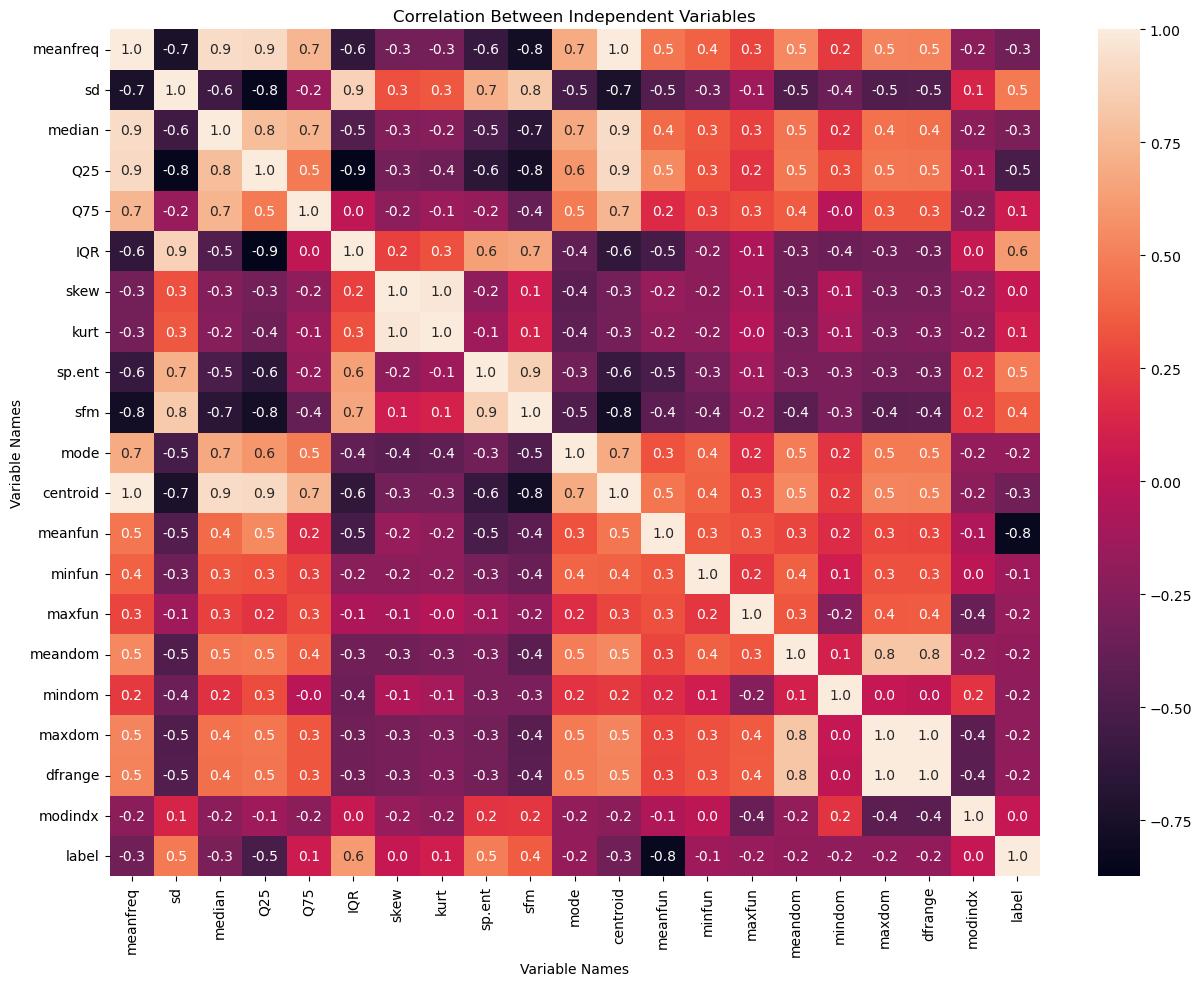

In [18]:
plt.figure(figsize = (15,11))
sns.heatmap(df.corr(), annot = True, fmt = '.1f')
plt.title('Correlation Between Independent Variables')
plt.xlabel('Variable Names')
plt.ylabel('Variable Names')
plt.show()

## Train Test Split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df['label'], test_size = 0.2, random_state = 32)

## Standardizing the Data

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train

array([[ 0.13038685, -1.00872894,  0.06893866, ...,  0.40210991,
         0.37119484,  1.05628447],
       [ 0.96303703,  0.5310491 ,  1.29068049, ...,  0.52853407,
         0.53692067,  0.76889551],
       [ 0.57780741, -1.45073095,  0.41434773, ...,  0.48493953,
         0.45187715,  0.38736072],
       ...,
       [ 0.07432727,  0.0696764 ,  0.26666698, ..., -0.35861481,
        -0.35058474, -0.23072458],
       [-0.85327722,  0.1280219 , -1.60672646, ..., -1.20244161,
        -1.18957174,  2.17988182],
       [ 0.20636926, -1.27566262, -0.07081177, ...,  1.50505176,
         1.46803813, -0.27671585]])

In [25]:
x_test

array([[-0.53467401,  0.27003816, -1.16345356, ..., -1.34167167,
        -1.32967548, -0.06554558],
       [-0.42725976,  0.26021566, -0.34781687, ..., -0.4065688 ,
        -0.40073861, -0.09343489],
       [-2.92829898,  1.25232138, -3.28925922, ..., -0.50465651,
        -0.49232394,  0.72791372],
       ...,
       [ 1.25097894, -1.1641805 ,  0.95988617, ..., -1.00817345,
        -0.99604322,  0.2076114 ],
       [ 0.57425146, -0.14352709,  0.79339692, ..., -0.84687365,
        -0.8346786 , -0.67617135],
       [ 0.86184795, -1.36097266,  0.63171025, ...,  0.40646936,
         0.4148069 , -0.63850675]])

## SVM Model with Default Hyper-Parameter (RBF Kernel)

In [27]:
from sklearn.svm import SVC

In [28]:
svm_model = SVC()
svm_model.fit(x_train, y_train)
pred = svm_model.predict(x_test)
pred

array([1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,

## Evaluation

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, precision_score

In [31]:
print('Accuracy of the Model is: ', accuracy_score(y_test, pred))

Accuracy of the Model is:  0.9873817034700315


## Linear Kernel

In [33]:
svm_linear = SVC(kernel = 'linear')
svm_linear.fit(x_train, y_train)
pred_linear = svm_linear.predict(x_test)
print('Accuracy of the Linear Kernel SVM Model is: ', accuracy_score(y_test, pred_linear))

Accuracy of the Linear Kernel SVM Model is:  0.9826498422712934


## Polynomial Kernel

In [35]:
svm_poly = SVC(kernel = 'poly')
svm_poly.fit(x_train, y_train)
pred_poly = svm_poly.predict(x_test)
print('Accuracy of the Linear Kernel SVM Model is: ', accuracy_score(y_test, pred_poly))

Accuracy of the Linear Kernel SVM Model is:  0.9716088328075709


## Optimization of Hyper-Parameter 'C'

In [88]:
x_ = np.concatenate([x_train, x_test], axis = 0)
X = pd.DataFrame(x_, columns = df.columns[:-1])

In [90]:
y_ = np.concatenate([y_train, y_test], axis = 0)
Y = pd.DataFrame(y_, columns = ['label'])

In [39]:
from sklearn.model_selection import cross_val_score

In [86]:
lst = [i for i in range(1,25)]
acc_score = []

for i in lst:
    svm_linear1 = SVC(kernel = 'linear', C = i)
    scores = cross_val_score(svm_linear1, X, Y, cv = 8, scoring = 'accuracy')
    acc_score.append(scores.mean())
print(acc_score)

[0.9744318181818181, 0.9741161616161615, 0.9741161616161615, 0.9744318181818181, 0.9741161616161615, 0.973800505050505, 0.973800505050505, 0.973800505050505, 0.9734848484848485, 0.973800505050505, 0.9738005050505051, 0.9734848484848485, 0.9734848484848485, 0.9734848484848485, 0.9734848484848485, 0.9738005050505051, 0.9734848484848485, 0.9734848484848485, 0.973800505050505, 0.973800505050505, 0.9734848484848485, 0.973800505050505, 0.973800505050505, 0.973800505050505]


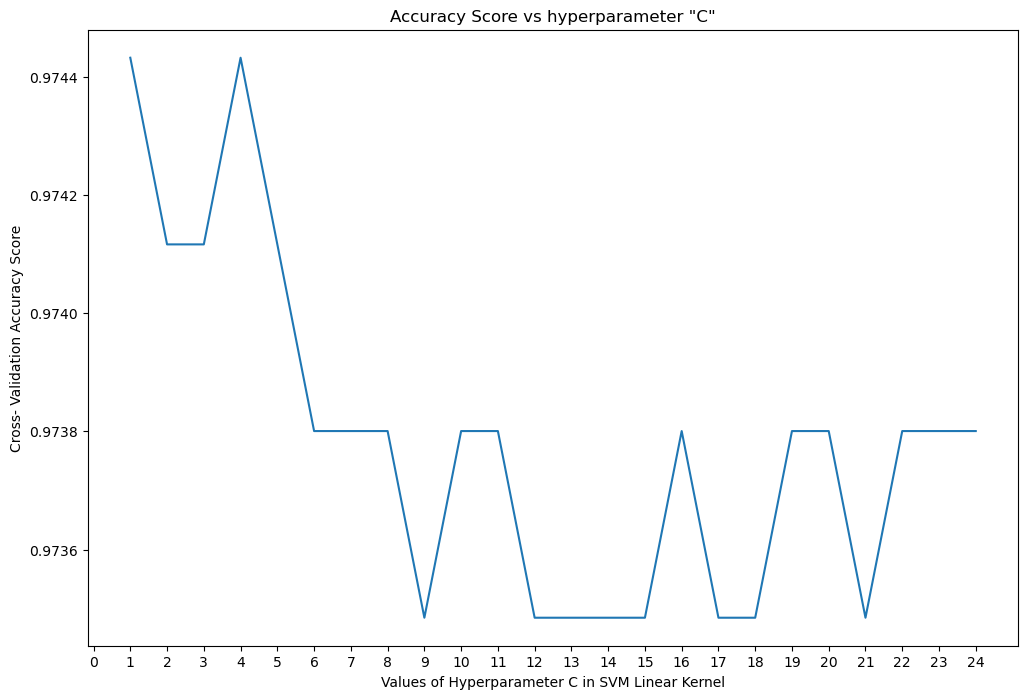

In [96]:
plt.figure(figsize = (12,8))
sns.lineplot(x = [i for i in range(1,25)], y = acc_score)
plt.xticks([i for i in range(25)])
plt.xlabel('Values of Hyperparameter C in SVM Linear Kernel')
plt.ylabel('Cross- Validation Accuracy Score')
plt.title('Accuracy Score vs hyperparameter "C"')
plt.show()

In [122]:
lst = np.arange(0.1, 2.0, 0.1)
acc_score = []

for i in lst:
    svm_linear2 = SVC(kernel = 'linear', C = i)
    scores = cross_val_score(svm_linear2, X, Y, cv = 10, scoring = 'accuracy')
    acc_score.append(scores.mean())
print(acc_score)

[0.975383340654075, 0.9744359701313741, 0.9738050553048756, 0.9741205127181249, 0.9744359701313741, 0.9750688815237792, 0.9750688815237792, 0.9750688815237792, 0.9750688815237792, 0.9741215110010781, 0.9741215110010781, 0.9741215110010781, 0.9741215110010781, 0.9741215110010781, 0.9741215110010781, 0.9744379666972807, 0.9741215110010781, 0.9744379666972807, 0.9744379666972807]


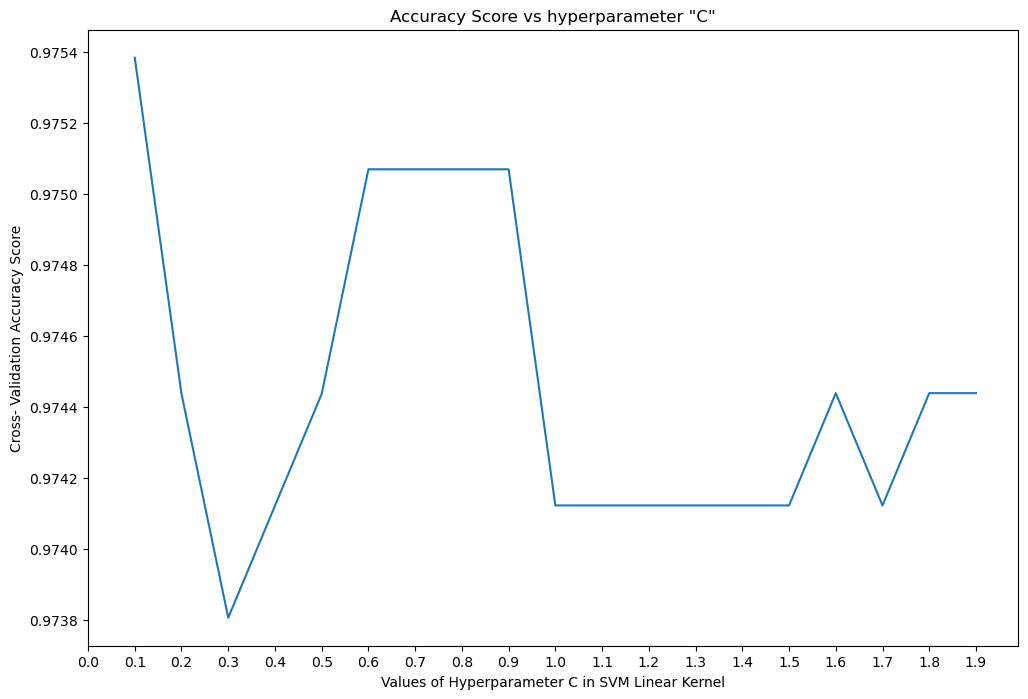

In [130]:
plt.figure(figsize = (12,8))
sns.lineplot(x = np.arange(0.1, 2.0, 0.1), y = acc_score)
plt.xticks(np.arange(0.0, 2.0, 0.1))
plt.xlabel('Values of Hyperparameter C in SVM Linear Kernel')
plt.ylabel('Cross- Validation Accuracy Score')
plt.title('Accuracy Score vs hyperparameter "C"')
plt.show()

## Optimization of Hyper-Parameter 'degree'

In [99]:
acc_score = []
d_lst = [i for i in range(1,10)]

for i in d_lst:
    svm_poly1 = SVC(kernel = 'poly', degree = i)
    score = cross_val_score(svm_poly1, X, Y, scoring = 'accuracy', cv = 8)
    acc_score.append(score.mean())

print(acc_score)

[0.973800505050505, 0.9046717171717171, 0.9605429292929293, 0.8778409090909092, 0.8873106060606061, 0.8090277777777778, 0.8039772727272727, 0.7452651515151516, 0.7458964646464646]


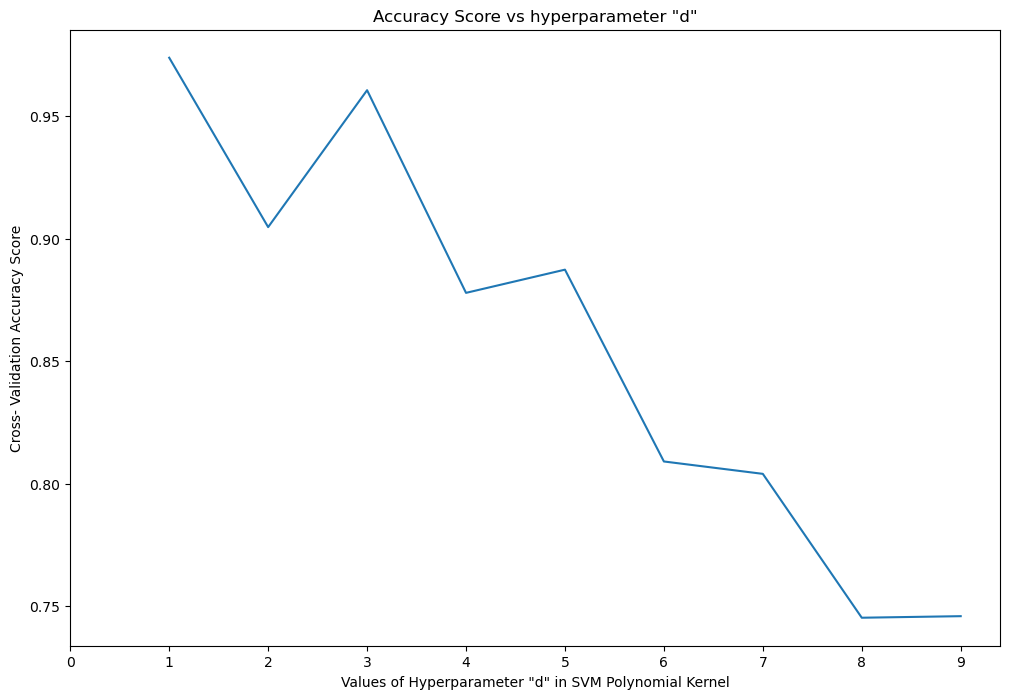

In [103]:
plt.figure(figsize = (12,8))
sns.lineplot(x = [i for i in range(1,10)], y = acc_score)
plt.xticks([i for i in range(10)])
plt.xlabel('Values of Hyperparameter "d" in SVM Polynomial Kernel')
plt.ylabel('Cross- Validation Accuracy Score')
plt.title('Accuracy Score vs hyperparameter "d"')
plt.show()

## Optimization of Hyper-Parameter 'gamma'

In [137]:
acc_score = []
gamma_lst = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
for i in gamma_lst:
    svm_rbf = SVC(gamma = i)
    score = cross_val_score(svm_rbf, X, Y, cv = 10, scoring = 'accuracy')
    acc_score.append(score.mean())

print(acc_score)

[0.8901549335143553, 0.9662330791039413, 0.974438964980234, 0.9832727708341652, 0.975374356107495, 0.6641426745996885, 0.49968454258675077]


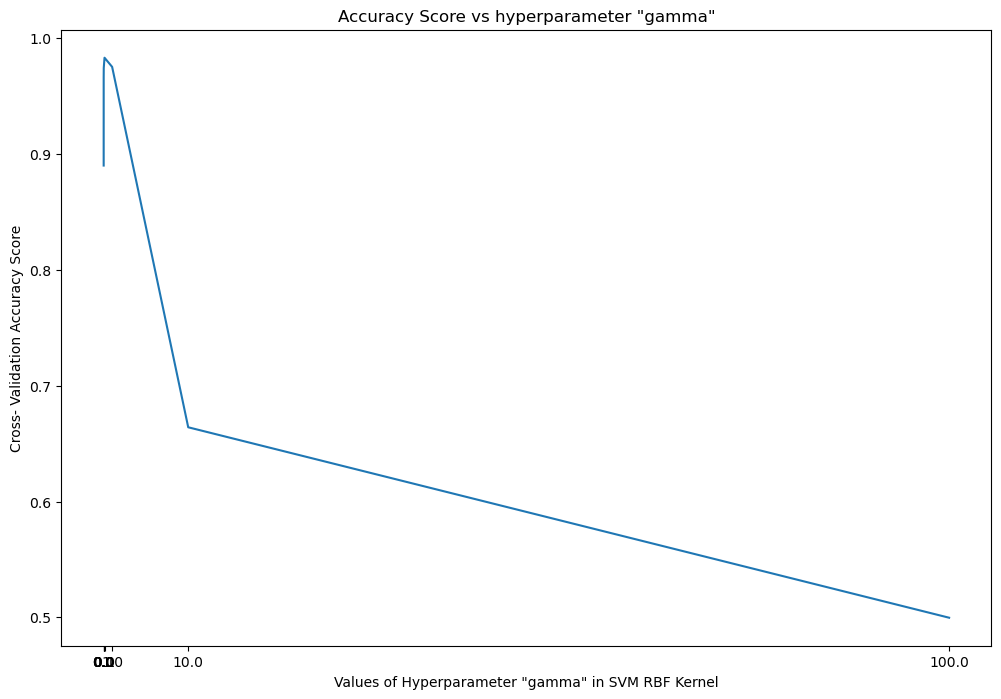

In [139]:
plt.figure(figsize = (12,8))
sns.lineplot(x = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100], y = acc_score)
plt.xticks([0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100])
plt.xlabel('Values of Hyperparameter "gamma" in SVM RBF Kernel')
plt.ylabel('Cross- Validation Accuracy Score')
plt.title('Accuracy Score vs hyperparameter "gamma"')
plt.show()

## Optimization of Hyper-Parameters using GridSearchCV

In [144]:
from sklearn.model_selection import GridSearchCV

In [146]:
tuned_parameter = {'C': np.arange(0.01, 1, 0.01), 'kernel': ['linear'],
                   'C': np.arange(0.01, 1, 0.01), 'gamma': [0.09, 0.1, 0.2, 0.3, 0.4, 0.5], 'degree': [1,2,3,4,5], 'kernel': ['RBF'],
                   'C': np.arange(0.01, 1, 0.01), 'degree': [1,2,3,4,5], 'kernel': ['poly']}
model_svm = GridSearchCV(svc, tuned_parameter, cv = 10, scoring = 'accuracy')

In [148]:
model_svm.fit(x_train, y_train)
print(model_svm.best_params_)
print(model_svm.best_score_)

{'C': 0.18000000000000002, 'degree': 3, 'gamma': 0.2, 'kernel': 'poly'}
0.9735535775419377


In [179]:
main_svm = SVC(C= 0.18000000000000002, degree= 3, gamma= 0.2, kernel= 'poly')
main_svm.fit(x_train, y_train)
pred_main = main_svm.predict(x_test)
print('Accuracy Score is: ', accuracy_score(y_test, pred_main))
pred_main

Accuracy Score is:  0.9779179810725552


array([1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,

In [181]:
y_test

603     1
795     1
1694    0
2727    0
371     1
       ..
1840    0
1677    0
1949    0
90      1
2497    0
Name: label, Length: 634, dtype: int32

## Evaluation of Model with Most Accurate Score

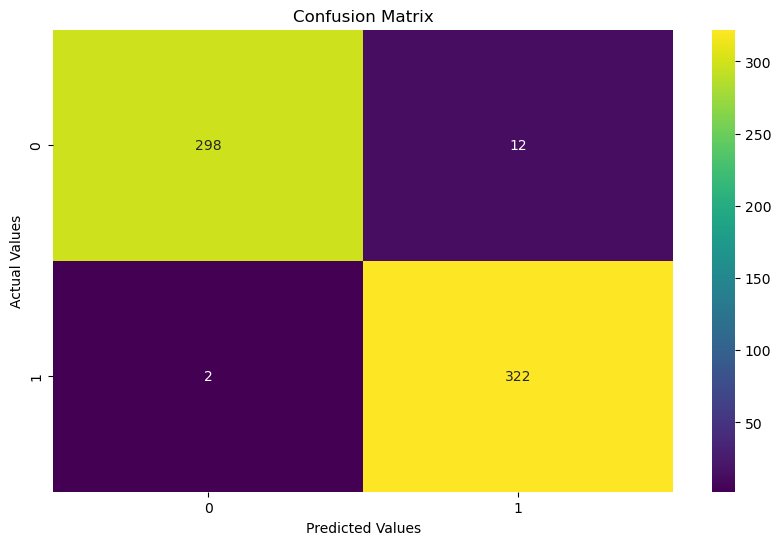

In [155]:
conf = confusion_matrix(y_test, pred_main)

plt.figure(figsize = (10,6))
sns.heatmap(conf, annot = True, fmt = 'd', cmap = 'viridis')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

In [157]:
print(classification_report(y_test, pred_main))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       310
           1       0.96      0.99      0.98       324

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



In [159]:
print('The Precision Score of the Model is: ', precision_score(y_test, pred_main))
print('The Recall Score of the Model is: ', recall_score(y_test, pred_main))

The Precision Score of the Model is:  0.9640718562874252
The Recall Score of the Model is:  0.9938271604938271


In [161]:
from sklearn.metrics import roc_curve, roc_auc_score

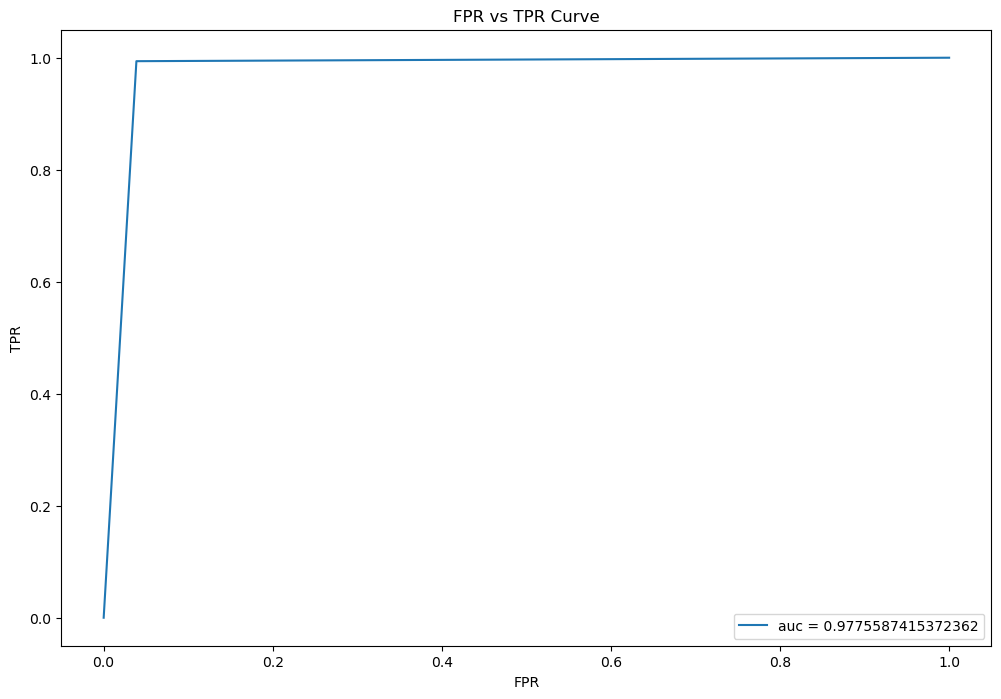

In [169]:
fpr, tpr, _ = roc_curve(y_test, pred_main)
auc_score = roc_auc_score(y_test, pred_main)

plt.figure(figsize = (12, 8))
sns.lineplot(x = fpr, y = tpr, label = 'auc = '+str(auc_score))
plt.title('FPR vs TPR Curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()